In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
plt.style.use('default')
plt.rc('figure', figsize=(15,10))
plt.rc('legend',fontsize=24)
plt.rc('axes',labelsize=28)
plt.rc('xtick',labelsize=24)
plt.rc('ytick',labelsize=24)

In [2]:
from BopFoxFeaturizer.FeatureConcatenate import stackdata
from BopFoxFeaturizer.brief_summary_parser import StructSummaryParser
from BopFoxFeaturizer.Featurizer import Featurizer
%run SourceDevelopementVersion.py
from BopFoxFeaturizer import  HelperFunctions as HF

In [3]:
BS = StructSummaryParser().BriefSummary
Features = Featurizer(BS)
Features.Mag[('NM' != Features.Mag) & ('FM' != Features.Mag)] = 'FiM'

In [4]:
def make_magnetic_feature(MagInfo):
    if MagInfo == 'NM':
        return 0
    elif MagInfo == 'NM':
        return 1
    else:
        return 2
    
def load_bop (BOPCOEF_FILE):
    # the momMags I calculated in some other ocasion - NSC canonical tight binding model
    BopfoxFeatures = pd.read_pickle(BOPCOEF_FILE)
    BopfoxFeatures.drop(columns=['NSC_U_bond_atom_list'], inplace=True)
    BopfoxFeatures.drop(columns=['NSC_U_bind'], inplace=True)
    ## clean features: reduntandly convert all features to float
    BopfoxFeatures.dropna(how='any',inplace=True)
    M = BopfoxFeatures['NSC_moments'].map(lambda M: np.array(M).mean(axis=0))
    S = BopfoxFeatures['NSC_SIGMA'].map(lambda M: np.array(M).mean(axis=0))
    Binf=BopfoxFeatures['NSC_Binf'].map(lambda s: [float(si) for si in s]).map(np.mean)
    Ainf=BopfoxFeatures['NSC_Ainf'].map(lambda s: [float(si) for si in s]).map(np.mean)
    AN = BopfoxFeatures['NSC_an'].map(lambda M: np.array(M).mean(axis=0))
    BN = BopfoxFeatures['NSC_bn'].map(lambda M: np.array(M).mean(axis=0))
    Mag = Features.Mag[BopfoxFeatures.index].map(make_magnetic_feature)
    Mag.name = 'MagConfig'
    BOP_atom_average = pd.concat([M, S, AN, BN, Ainf, Binf, Mag], axis=1)
    # Feature Transformation to concatenation
    BOP, names = stackdata(BOP_atom_average, BOP_atom_average.columns.values)
    BOP = pd.DataFrame(data=BOP, columns=names, index = BOP_atom_average.index)
    featurenames = HF.cleanfeaturenames(names)
    feature_titles = pd.Series(
        HF.cleanfeaturenames([ s.replace('NSC_','') for s in names ]), index=names
    )
    return BOP.dropna(), feature_titles

In [5]:
FILE_INITIAL = 'CRCOW_INITIAL_NSC_CANONICAL_HISTCUTOFF.pkl'
FILE_RELAXED =  'CRCOW_RELAXED_NSC_CANONICAL_HISTCUTOFF.pkl'
FILE_INITIAL_ORTHO = 'CRCOW_INITIAL_NSC_ORTHOGONAL_TABLECUTOFF.pkl'
FILE_INITIAL_TABLECUTOFF = 'CRCOW_INITIAL_NSC_CANONICAL_TABLECUTOFF.pkl'

In [6]:
def get_columns_groups(BOP):
    columns_bn = BOP.columns[BOP.columns.str.contains('bn')]
    columns_sigma =BOP.columns[BOP.columns.str.contains('SIGMA')] 
    columns_moments = BOP.columns[BOP.columns.str.contains('moment')]
    columns_an = BOP.columns[BOP.columns.str.contains('an')]
    return {'an': columns_an, 'bn': columns_bn, 'moments': columns_moments, 'sigma': columns_sigma}

In [7]:
def get_good_columns_groups(real_feature):
    useful_an = [f for f in real_feature if 'an' in f]
    useful_bn = [f for f in real_feature if 'bn' in f]
    useful_moment = [f for f in real_feature if 'moment' in f]
    useful_sigmas = [f for f in real_feature if 'SIGMA' in f]
    return {'an': useful_an, 'bn': useful_bn, 'moments': useful_moment, 'sigma': useful_sigmas}

In [8]:
INITIAL, titlesini = load_bop(FILE_INITIAL)

In [9]:
RELAXED, titlesrlx = load_bop(FILE_RELAXED)

In [10]:
INITABLE, titlestableini = load_bop(FILE_INITIAL_TABLECUTOFF)

In [16]:
INITABLEORTH, titlestableiniorth = load_bop(FILE_INITIAL_ORTHO)

In [11]:
column_groups = get_columns_groups(INITIAL)

In [12]:
real_features_initial = get_good_columns_groups(HF.get_useful_features(INITIAL,INITIAL.columns))

In [13]:
real_features_relaxed = get_good_columns_groups(HF.get_useful_features(RELAXED, RELAXED.columns))

In [14]:
real_features_initable = get_good_columns_groups(HF.get_useful_features(INITABLE, INITABLE.columns))

In [17]:
real_features_initable_orth = get_good_columns_groups(HF.get_useful_features(INITABLE, INITABLE.columns))

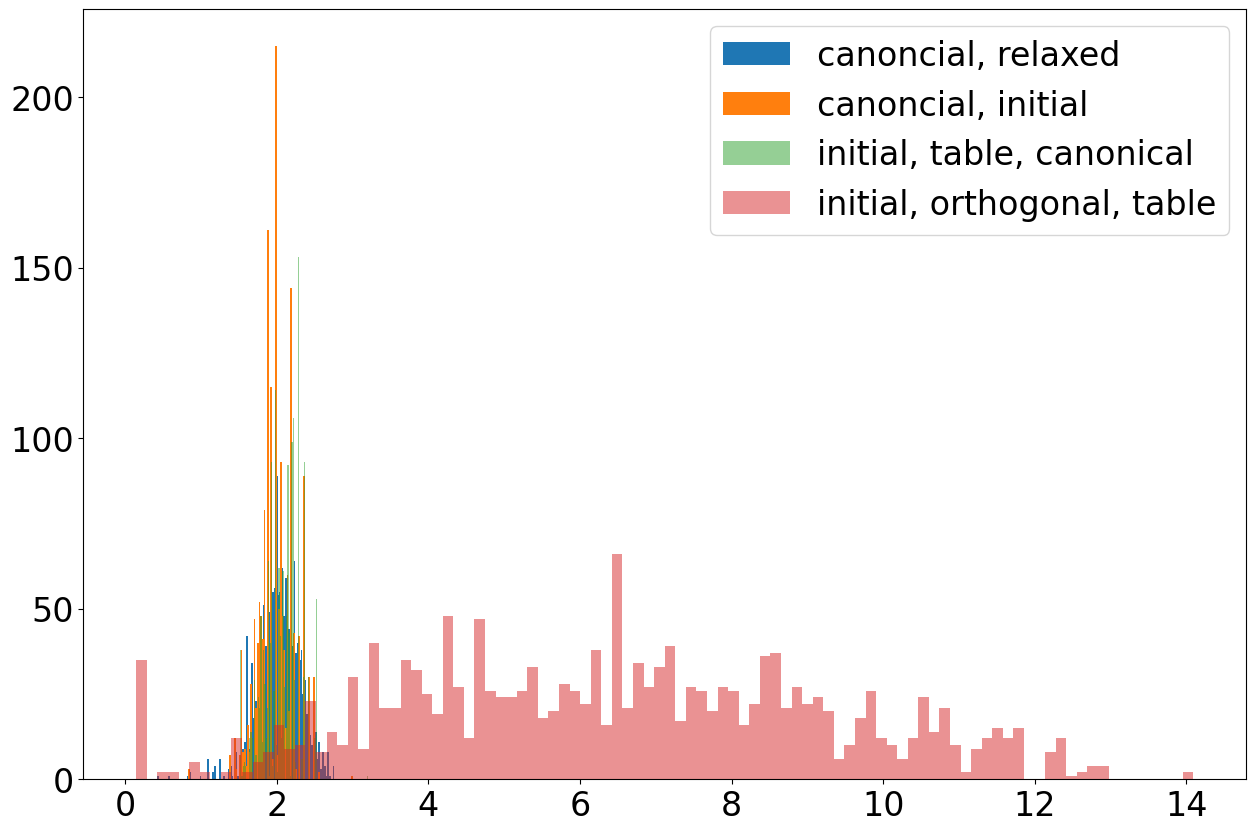

In [20]:
compare = 'NSC_moments_1'
histrlx = plt.hist(RELAXED[compare], bins=100,label='canoncial, relaxed')
histini = plt.hist(INITIAL[compare], bins=100,label='canoncial, initial')
histabl = plt.hist(INITABLE[compare], bins=100, alpha=0.5,label='initial, table, canonical')
historth = plt.hist(INITABLEORTH[compare], bins=100, alpha=0.5,label='initial, orthogonal, table')
plt.legend()


In [25]:
INITIAL.shape

(1684, 85)

In [26]:
RELAXED.shape

(1663, 85)